# **ENVIROMENT INITIALIZATION**

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import sklearn

import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("polars:", pl.__version__)
print("sklearn:", sklearn.__version__)

from pathlib import Path
import os

from datetime import date, timedelta

numpy: 2.4.5
pandas: 3.0.3
polars: 1.43.2
sklearn: 1.8.0


In [2]:
# PATH MARKING
# Death moment for my kitty paws, restore path to fit your needs
print("Curent path:", os.getcwd())

DATASET_PATH = Path("D:\\.workspace\\Programming\\Projects\\E-cup_2026_by_Ozon_Tech\\data\\raw\\train.parquet")

PROJECT_ROOT = Path(r"D:\\.workspace\\Programming\\Projects\\E-cup_2026_by_Ozon_Tech")

REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents = True, exist_ok = True)

print("DATASET exists:", DATASET_PATH.exists())

print(DATASET_PATH.exists())
print(DATASET_PATH.stat().st_size / 1024 / 1024, "MB")

Curent path: d:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\notebooks
DATASET exists: True
True
171.80338954925537 MB


# **CUSTOM FUNCTIONS**

In [3]:
# FUNCTION FOR CONVERTING POLAR TABLES IN EDA
def print_vertical_one_row(df: pl.DataFrame) -> None:
    """
    It conveniently prints wide tables with a single line.
    If there are more lines, it prints a table with expanded output.
    """
    if df.height == 0:
        print("Empty DataFrame")
        return

    if df.height == 1:
        row = df.row(0)
        for col_name, value in zip(df.columns, row):
            print(f"{col_name:45} {value}")
    else:
        with pl.Config() as cfg:
            cfg.set_tbl_cols(-1)
            cfg.set_tbl_width_chars(-1)
            cfg.set_tbl_rows(-1)
            print(df)

# **EXPLORATORY DATA ANALISYS - DATA AUDIT**

### **ABOUT DATASET:**
- **event_date** – дата с 2025-01-01 по 2026-02-13
- **user_id** — идентификатор пользователя
- **search** – флаг пользования Поиском (0 или 1)
- **cat** – флаг пользования Каталогом (0 или 1)
- **has_search_to_cart** – флаг переноса товара в корзину при пользовании Поиском (0 или 1)
- **has_search_to_ord** – флаг покупки товара при пользовании Поиском (0 или 1)
- **has_cat_to_cart** – флаг переноса товара в корзину при пользовании Каталогом (0 или 1)
- **has_cat_to_ord** – флаг покупки товара при пользовании Каталогом (0 или 1)
- **search_to_cart** – число добавленных в корзину товаров при пользовании Поиском
- **search_to_ord** – число купленных товаров при пользовании Поиском 
- **cat_to_cart** – число добавленных в корзину товаров при пользовании Каталогом
- **cat_to_ord** – число купленных товаров при пользовании Каталогом 
- **gmv_search** – суммарная стоимость купленных товаров при пользовании Поиском
- **gmv_cat** – суммарная стоимость купленных товаров при пользовании Каталогом
- **to_cart** – суммарное число добавленных в корзину товаров
- **to_ord** – суммарное число купленных товаров
- **gmv** – суммарная стоимость купленных товаров
- **searches** – суммарное число поисковых запросов

In [4]:
# CREATING LAZY FRAME WITH POLARS
lf = pl.scan_parquet(DATASET_PATH)

In [5]:
# FORMAT CHECKING
schema = lf.collect_schema()

for col_name, col_type in schema.items():
    print(f"{col_name:20} {col_type}")

event_date           Date
user_id              Int64
search               Int64
cat                  Int64
has_search_to_cart   Int64
has_search_to_ord    Int64
has_cat_to_cart      Int64
has_cat_to_ord       Int64
search_to_cart       Int64
search_to_ord        Int64
cat_to_cart          Int64
cat_to_ord           Int64
gmv_search           Float64
gmv_cat              Float64
to_cart              Int64
to_ord               Int64
gmv                  Float64
searches             Int64


In [6]:
# GLIMPSE SOME OBSERVATIONS
lf.head(20).collect()

event_date,user_id,search,cat,has_search_to_cart,has_search_to_ord,has_cat_to_cart,has_cat_to_ord,search_to_cart,search_to_ord,cat_to_cart,cat_to_ord,gmv_search,gmv_cat,to_cart,to_ord,gmv,searches
date,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,i64,i64,f64,i64
2025-06-16,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,2
2025-06-22,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-08,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2025-08-18,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,1
2025-08-23,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2026-02-01,2,1,0,1,0,0,0,1,0,0,0,0.0,0.0,1,0,0.0,5
2026-02-06,2,1,0,0,0,0,0,0,0,0,0,0.0,0.0,0,0,0.0,1
2026-02-11,2,1,0,1,0,0,0,2,0,0,0,0.0,0.0,2,0,0.0,1


In [7]:
# GETTING A NUMBER OF OBSERVATIONS
lf.select(pl.len()).collect()

len
u32
30631006


In [8]:
# OBSERVATIONS INFO
USER_COL = "user_id"

n_users = lf.select(pl.col(USER_COL).n_unique()).collect().item()
print("Unique users:", n_users)

# TIME COLUMN INFO
DATE_COL = "event_date"

date_stats = lf.select(
    pl.col(DATE_COL).min().alias("min_date"),
    pl.col(DATE_COL).max().alias("max_date")
).collect()

print(date_stats)

# GMV INFO
REVENUE_COL = "gmv"

revenue_stats = lf.select(
    pl.col(REVENUE_COL).min().alias("min"), 
    pl.col(REVENUE_COL).mean().alias("mean"),
    pl.col(REVENUE_COL).median().alias("median"),
    pl.col(REVENUE_COL).max().alias("max"),
    pl.col(REVENUE_COL).sum().alias("total"),

    (pl.col(REVENUE_COL) > 0).mean().alias("share_positive")
).collect()

print(revenue_stats)

Unique users: 250000
shape: (1, 2)
┌────────────┬────────────┐
│ min_date   ┆ max_date   │
│ ---        ┆ ---        │
│ date       ┆ date       │
╞════════════╪════════════╡
│ 2025-01-01 ┆ 2026-02-13 │
└────────────┴────────────┘
shape: (1, 6)
┌─────┬──────────┬────────┬──────────────┬──────────┬────────────────┐
│ min ┆ mean     ┆ median ┆ max          ┆ total    ┆ share_positive │
│ --- ┆ ---      ┆ ---    ┆ ---          ┆ ---      ┆ ---            │
│ f64 ┆ f64      ┆ f64    ┆ f64          ┆ f64      ┆ f64            │
╞═════╪══════════╪════════╪══════════════╪══════════╪════════════════╡
│ 0.0 ┆ 8.883207 ┆ 0.0    ┆ 73830.297037 ┆ 2.7210e8 ┆ 0.154644       │
└─────┴──────────┴────────┴──────────────┴──────────┴────────────────┘


## **CHECKING FOR MISSINGS, DUBLICATES ETC.**

In [9]:
# SEARCHING FOR NULLS IN DATA
null_counts = lf.select(pl.all().null_count()).collect()
print_vertical_one_row(null_counts)

event_date                                    0
user_id                                       0
search                                        0
cat                                           0
has_search_to_cart                            0
has_search_to_ord                             0
has_cat_to_cart                               0
has_cat_to_ord                                0
search_to_cart                                0
search_to_ord                                 0
cat_to_cart                                   0
cat_to_ord                                    0
gmv_search                                    0
gmv_cat                                       0
to_cart                                       0
to_ord                                        0
gmv                                           0
searches                                      0


In [10]:
# CHECKING IF NaN IN FLOAT COLUMNS
float_cols = [
    col for col, dtype in schema.items()
    if dtype == pl.Float64]

print("Float columns:", float_cols)

if float_cols:
    nan_counts = lf.select(
        [pl.col(c).is_nan().sum().alias(c) for c in float_cols]
    ).collect()
    print(nan_counts)

Float columns: ['gmv_search', 'gmv_cat', 'gmv']
shape: (1, 3)
┌────────────┬─────────┬─────┐
│ gmv_search ┆ gmv_cat ┆ gmv │
│ ---        ┆ ---     ┆ --- │
│ u32        ┆ u32     ┆ u32 │
╞════════════╪═════════╪═════╡
│ 0          ┆ 0       ┆ 0   │
└────────────┴─────────┴─────┘


In [11]:
# CHECKING IF DUBLICATES IN USERS BY A DAY
# If dublicates in -> must be combined
duplicates = (
    lf.group_by(["user_id", "event_date"])
      .len()
      .filter(pl.col("len") > 1)
)

print(duplicates.collect())

shape: (0, 3)
┌─────────┬────────────┬─────┐
│ user_id ┆ event_date ┆ len │
│ ---     ┆ ---        ┆ --- │
│ i64     ┆ date       ┆ u32 │
╞═════════╪════════════╪═════╡
└─────────┴────────────┴─────┘


In [12]:
# CHECKING GMV FOR MISMATCHES
gmv_check = lf.select(
    pl.len().alias("rows"),
    pl.col("gmv").is_null().sum().alias("gmv_nulls"),
    pl.col("gmv_search").is_null().sum().alias("gmv_search_nulls"),
    pl.col("gmv_cat").is_null().sum().alias("gmv_cat_nulls"),
    (pl.col("gmv") < 0).sum().alias("gmv_negative"),
    (pl.col("gmv_search") < 0).sum().alias("gmv_search_negative"),
    (pl.col("gmv_cat") < 0).sum().alias("gmv_cat_negative"),
    (
        (
            pl.col("gmv").fill_null(0.0)
            - (
                pl.col("gmv_search").fill_null(0.0)
                + pl.col("gmv_cat").fill_null(0.0)
            )
        ).abs() > 1e-6
    ).sum().alias("gmv_not_equal_sum")
).collect()

print(gmv_check)

shape: (1, 8)
┌──────────┬───────────┬────────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ rows     ┆ gmv_nulls ┆ gmv_search ┆ gmv_cat_nu ┆ gmv_negati ┆ gmv_search ┆ gmv_cat_n ┆ gmv_not_e │
│ ---      ┆ ---       ┆ _nulls     ┆ lls        ┆ ve         ┆ _negative  ┆ egative   ┆ qual_sum  │
│ u32      ┆ u32       ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│          ┆           ┆ u32        ┆ u32        ┆ u32        ┆ u32        ┆ u32       ┆ u32       │
╞══════════╪═══════════╪════════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 30631006 ┆ 0         ┆ 0          ┆ 0          ┆ 0          ┆ 0          ┆ 0         ┆ 0         │
└──────────┴───────────┴────────────┴────────────┴────────────┴────────────┴───────────┴───────────┘


In [13]:
# CHECKING IF TROUBLES IN BINARY COLUMNS
binary_cols = [
    "search",
    "cat",
    "has_search_to_cart",
    "has_search_to_ord",
    "has_cat_to_cart",
    "has_cat_to_ord",
]

binary_exprs = []

for c in binary_cols:
    binary_exprs.extend([
        pl.col(c).min().alias(f"{c}_min"),
        pl.col(c).max().alias(f"{c}_max"),
        pl.col(c).n_unique().alias(f"{c}_uniq"),
        ((pl.col(c) != 0) & (pl.col(c) != 1)).sum().alias(f"{c}_not_0_1"),
    ])

binary_stats = lf.select(binary_exprs).collect()

print_vertical_one_row(binary_stats)

search_min                                    0
search_max                                    1
search_uniq                                   2
search_not_0_1                                0
cat_min                                       0
cat_max                                       1
cat_uniq                                      2
cat_not_0_1                                   0
has_search_to_cart_min                        0
has_search_to_cart_max                        1
has_search_to_cart_uniq                       2
has_search_to_cart_not_0_1                    0
has_search_to_ord_min                         0
has_search_to_ord_max                         1
has_search_to_ord_uniq                        2
has_search_to_ord_not_0_1                     0
has_cat_to_cart_min                           0
has_cat_to_cart_max                           1
has_cat_to_cart_uniq                          2
has_cat_to_cart_not_0_1                       0
has_cat_to_ord_min                      

In [14]:
# CHECKING OTHER COLUMNS
count_cols = [
    "search_to_cart",
    "search_to_ord",
    "cat_to_cart",
    "cat_to_ord",
    "to_cart",
    "to_ord",
    "searches",
]

count_exprs = []

for c in count_cols:
    count_exprs.extend([
        pl.col(c).min().alias(f"{c}_min"),
        pl.col(c).max().alias(f"{c}_max"),
        pl.col(c).median().alias(f"{c}_median"),
        pl.col(c).n_unique().alias(f"{c}_uniq"),
        (pl.col(c) < 0).sum().alias(f"{c}_negative"),
    ])

count_stats = lf.select(count_exprs).collect()

print_vertical_one_row(count_stats)

search_to_cart_min                            0
search_to_cart_max                            816
search_to_cart_median                         0.0
search_to_cart_uniq                           240
search_to_cart_negative                       0
search_to_ord_min                             0
search_to_ord_max                             138
search_to_ord_median                          0.0
search_to_ord_uniq                            74
search_to_ord_negative                        0
cat_to_cart_min                               0
cat_to_cart_max                               1535
cat_to_cart_median                            0.0
cat_to_cart_uniq                              158
cat_to_cart_negative                          0
cat_to_ord_min                                0
cat_to_ord_max                                68
cat_to_ord_median                             0.0
cat_to_ord_uniq                               41
cat_to_ord_negative                           0
to_cart_min       

### **Conclusion:**
- We have no nulls in data
- We have no NaN in float columns
- We have no dublicates in users grouped by day
- `gmv` = `gmv_search` + `gmv_cat`

*Data is well prepared for working*

## **WORKING WITH LOCAL TARGET BY TIME SPLIT**
*The Case implies time series split method for validation, so we have to check for cold-start users or other anomalies*

In [15]:
# DATATIME SPLIT
AS_OF = date(2026, 1, 14)
TARGET_END = AS_OF + timedelta(days = 30)

print("Feature cutoff:", AS_OF)
print("Target end:", TARGET_END)

Feature cutoff: 2026-01-14
Target end: 2026-02-13


In [16]:
# CHECKING USERS BEFOR AS_OF TIMEPOS FOR DETECTION COLD-START ANOMALIES
# If hist_users is significantly smaller than all_users, it means there are cold‑start users without any history prior to date
hist_users = (
    lf.filter(pl.col("event_date") <= AS_OF)
      .select(pl.col("user_id").n_unique())
      .collect()
      .item()
)

all_users = (
    lf.select(pl.col("user_id").n_unique())
      .collect()
      .item()
)

print("Users with history before cutoff:", hist_users)
print("All users:", all_users)

Users with history before cutoff: 250000
All users: 250000


In [17]:
# FILTERING THE FUTURE WINDOW
future_lf = lf.filter(
    (pl.col("event_date") > AS_OF) &
    (pl.col("event_date") <= TARGET_END)
)

# SANITY CHECK
future_dates = future_lf.select(
    pl.col("event_date").min().alias("min_target_date"),
    pl.col("event_date").max().alias("max_target_date"),
    pl.len().alias("rows_in_target_window")
).collect()

print_vertical_one_row(future_dates)

target_lf = (
    future_lf
    .group_by("user_id")
    .agg(pl.col("gmv").sum().alias("target"))
)

users_lf = lf.select(pl.col("user_id").unique())

cv_target_lf = (
    users_lf
    .join(target_lf, on = "user_id", how = "left")
    .with_columns(pl.col("target").fill_null(0.0))
)

cv_target = cv_target_lf.collect()

print(cv_target.head())

min_target_date                               2026-01-15
max_target_date                               2026-02-13
rows_in_target_window                         2793967
shape: (5, 2)
┌─────────┬───────────┐
│ user_id ┆ target    │
│ ---     ┆ ---       │
│ i64     ┆ f64       │
╞═════════╪═══════════╡
│ 2       ┆ 0.0       │
│ 7       ┆ 486.96535 │
│ 15      ┆ 0.0       │
│ 18      ┆ 276.0091  │
│ 23      ┆ 0.0       │
└─────────┴───────────┘


In [18]:
# SAVING THE TARGET DATAFRAME
cv_target.write_parquet("D:\\.workspace\\Programming\\Projects\\E-cup_2026_by_Ozon_Tech\\data\\processed\\cv_target_2026-01-14.parquet")

In [19]:
# CHECKING THE DISTRIBUTION OF LOCAL TARGET.
target_stats = (
    cv_target_lf
    .select(
        pl.len().alias("users"),
        pl.col("target").mean().alias("mean"),
        pl.col("target").median().alias("median"),
        pl.col("target").max().alias("max"),
        (pl.col("target") == 0).mean().alias("zero_share"),
        (pl.col("target") > 0).mean().alias("positive_share"),
        pl.col("target").quantile(0.50).alias("q50"),
        pl.col("target").quantile(0.90).alias("q90"),
        pl.col("target").quantile(0.99).alias("q99"),
        pl.col("target").quantile(0.999).alias("q999"),
    )
    .collect()
)

print_vertical_one_row(target_stats)

users                                         250000
mean                                          84.03404163321818
median                                        7.892407667220075
max                                           53746.95081219209
zero_share                                    0.45934
positive_share                                0.54066
q50                                           7.89315777057838
q90                                           215.86061923975788
q99                                           1040.1368388909743
q999                                          2933.555568355758


### **Conclusion:**
- Data time split went successfully.

### **Some thoughts:**
- Gotta look at the target destribution since the mean is significantly higher compared to the median;
- Need to use log1p(gmv) transformation;
- Cannot simply remove “outliers” thoughtlessly, need to look at the top users separately later for detection of special patterns;
- Cannot use only 0 or only 1 predicting baseline for everyone because 54% of users have a positive target.

## **01 - GMV ANALISYS**

In [20]:
# COLLECTING WEEKLY GMV AMOUNTS
weekly = (
    lf.with_columns(
        pl.col("event_date").dt.truncate("1w").alias("week")
    )
    .group_by("week")
    .agg(
        pl.col("event_date").n_unique().alias("days_in_week"),
        pl.col("gmv").sum().alias("gmv_sum"),
        pl.col("gmv_search").sum().alias("gmv_search_sum"),
        pl.col("gmv_cat").sum().alias("gmv_cat_sum"),
        pl.col("to_ord").sum().alias("orders_sum"),
        pl.col("user_id").n_unique().alias("active_users"),
    )
    .sort("week")
    .collect()
)

# 1st and last weeks may be incomplete. We take only full weeks for the schedules
weekly_full = weekly.filter(pl.col("days_in_week") == 7)

print(weekly_full.head(10))
print(weekly_full.tail(10))

shape: (10, 7)
┌────────────┬──────────────┬──────────┬───────────────┬───────────────┬────────────┬──────────────┐
│ week       ┆ days_in_week ┆ gmv_sum  ┆ gmv_search_su ┆ gmv_cat_sum   ┆ orders_sum ┆ active_users │
│ ---        ┆ ---          ┆ ---      ┆ m             ┆ ---           ┆ ---        ┆ ---          │
│ date       ┆ u32          ┆ f64      ┆ ---           ┆ f64           ┆ i64        ┆ u32          │
│            ┆              ┆          ┆ f64           ┆               ┆            ┆              │
╞════════════╪══════════════╪══════════╪═══════════════╪═══════════════╪════════════╪══════════════╡
│ 2025-01-06 ┆ 7            ┆ 3.3868e6 ┆ 3.0826e6      ┆ 304197.189807 ┆ 94240      ┆ 141551       │
│ 2025-01-13 ┆ 7            ┆ 3.3860e6 ┆ 3.0789e6      ┆ 307112.832088 ┆ 93756      ┆ 141903       │
│ 2025-01-20 ┆ 7            ┆ 3.2687e6 ┆ 2.9813e6      ┆ 287440.9936   ┆ 92623      ┆ 142298       │
│ 2025-01-27 ┆ 7            ┆ 3.2119e6 ┆ 2.9126e6      ┆ 299269.450008 ┆ 892

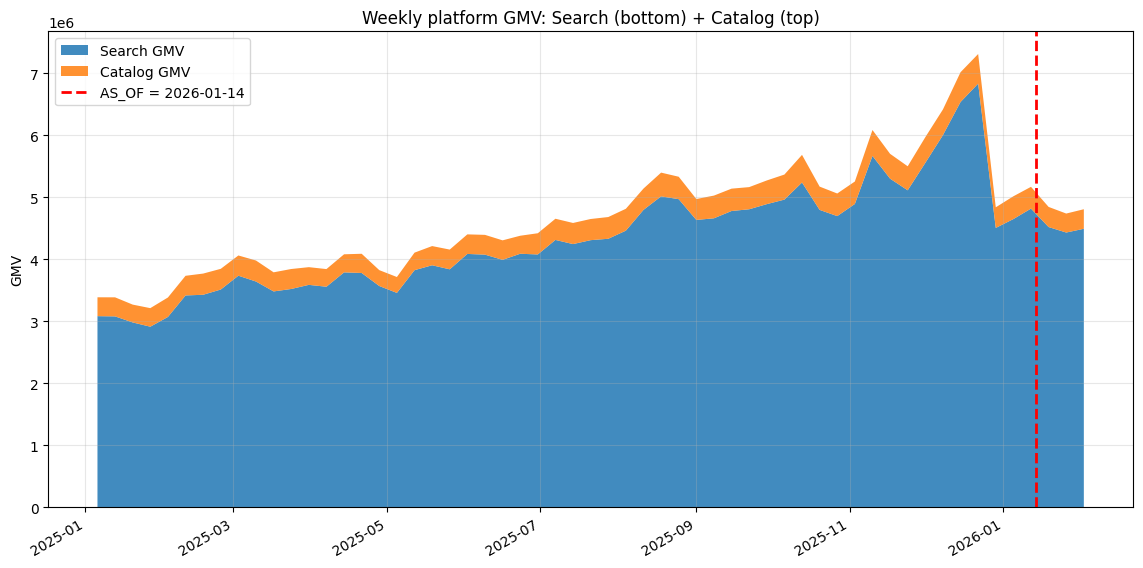

In [21]:
# STACKED AREA: CEARCH + CATALOG
weeks = weekly_full["week"].to_list()
search_vals = weekly_full["gmv_search_sum"].to_numpy()
cat_vals = weekly_full["gmv_cat_sum"].to_numpy()

fig, ax = plt.subplots(figsize = (14, 7))

ax.stackplot(
    weeks,
    search_vals,
    cat_vals,
    labels = ["Search GMV", "Catalog GMV"],
    alpha = 0.85,
)

ax.axvline(AS_OF, color = "red", linestyle = "--", linewidth = 2, label = "AS_OF = 2026-01-14")

ax.set_title("Weekly platform GMV: Search (bottom) + Catalog (top)")
ax.set_ylabel("GMV")
ax.legend(loc = "upper left")
ax.grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_DIR / "01_weekly_gmv_stacked.png", dpi = 150)
plt.show()

### **Some thoughts:**
**Global trends**
1. Platform has positive monotonic growth with local peaks;
2. Accelerating growth by the end of the year;
3. Catalog GMV is much lower compared to search GMV and does not repeat the behavior in local and global trends. So there is no flows between catalog and search. Channels have different natures, and they need to be handled differently in features.

**Local trends that depend on holidays etc**
1. Local grows: 2nd-3th weeks of February (23rd of February), 1st week of March (8th of March), 1st week of May (9th of May), 3rd-4th weeks of August (September: new School year), 1st-2nd weeks of October (Halloween), 1st week of November (4th of November), 4th week of November - 4th week of December (New Year);
2. Mounthly 2-cyclic growth after 10th and 25th days (double-payment salaries);
3. Local declines as expected after holidays and close befor salaries.

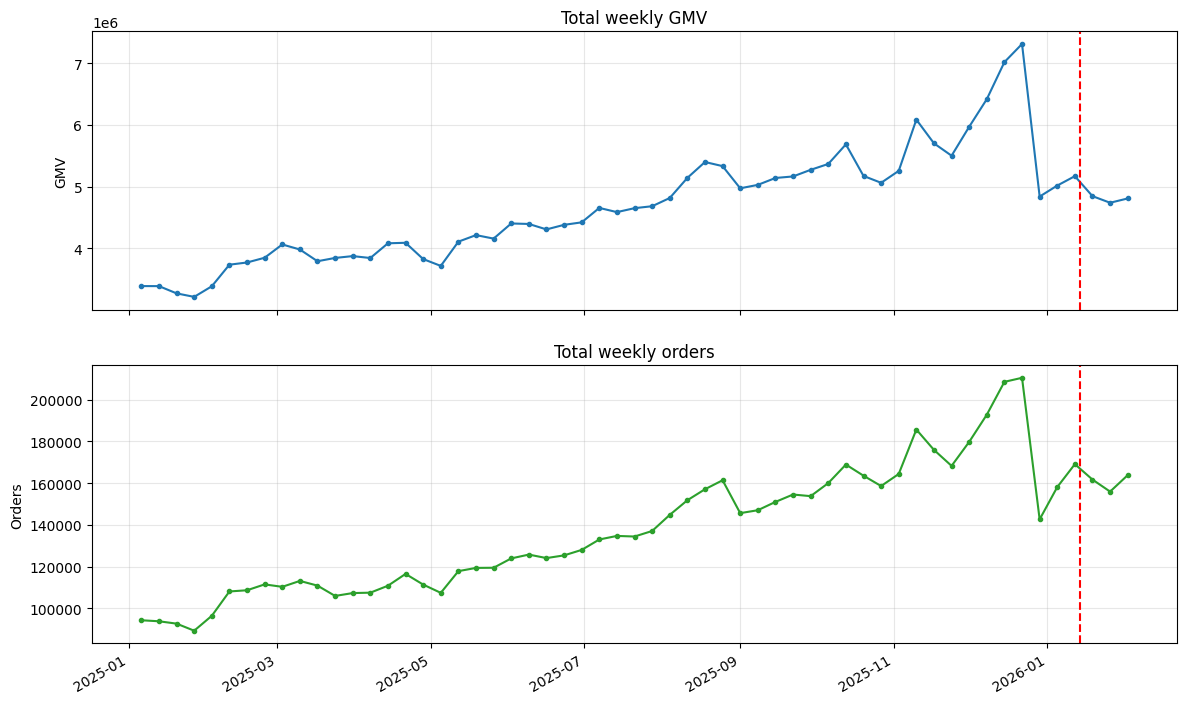

In [22]:
# OVERALL DYNAMICS OF GMV AND ORDERS BY WEEK
fig, axes = plt.subplots(2, 1, figsize = (14, 9), sharex = True)

# TOTAL GMV
axes[0].plot(
    weekly_full["week"],
    weekly_full["gmv_sum"],
    marker = "o",
    markersize = 3,
    color = "tab:blue",
)
axes[0].axvline(AS_OF, color = "red", linestyle = "--")
axes[0].set_title("Total weekly GMV")
axes[0].set_ylabel("GMV")
axes[0].grid(alpha = 0.3)

# ORDERS
axes[1].plot(
    weekly_full["week"],
    weekly_full["orders_sum"],
    marker = "o",
    markersize = 3,
    color = "tab:green",
)
axes[1].axvline(AS_OF, color = "red", linestyle = "--")
axes[1].set_title("Total weekly orders")
axes[1].set_ylabel("Orders")
axes[1].grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_DIR / "02_weekly_gmv_and_orders.png", dpi = 150)
plt.show()

### **Some thoughts:**
- We can see some artefacts in compression male vs female holidays using GMV to orders ratio. For example 23rd February: the is no peak in GMV unlike number of orders compared to the week before. But looking at 8th March: we see peak in GMV, but a lower peak in number of orders. So the difference is in mean price of order.
- And so on. We can see difference in mean price of order depending on different dates. As we can compare significance of holiday, we can see trend: the lower significance, the lower mean price, so then GMV grows thank to number of orders, not to amount of the check; and inverse.

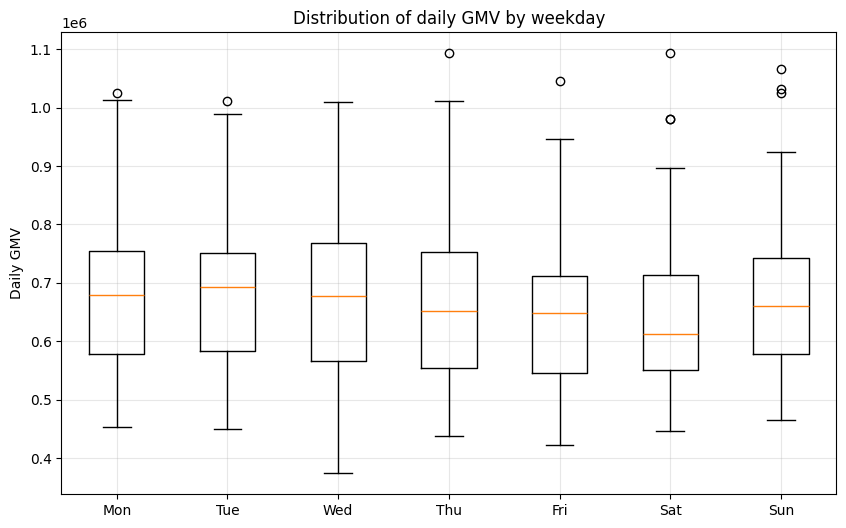

In [23]:
# DAILY AGREGATION + WEEKLY CYCLES
daily = (
    lf.group_by("event_date")
    .agg(
        pl.col("gmv").sum().alias("gmv_sum"),
        pl.col("to_ord").sum().alias("orders_sum"),
        pl.col("user_id").n_unique().alias("active_users"),
    )
    .with_columns(
        pl.col("event_date").dt.weekday().alias("weekday")
    )
    .sort("event_date")
    .collect()
)

WEEKDAY_LABELS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

data_by_weekday = [
    daily.filter(pl.col("weekday") == w)["gmv_sum"].to_numpy()
    for w in range(1, 8)
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.boxplot(data_by_weekday)
ax.set_xticks(range(1, 8))
ax.set_xticklabels(WEEKDAY_LABELS)

ax.set_title("Distribution of daily GMV by weekday")
ax.set_ylabel("Daily GMV")
ax.grid(alpha=0.3)

fig.savefig(REPORTS_DIR / "03_weekday_seasonality_boxplot.png", dpi = 150)
plt.show()

shape: (7, 3)
┌─────────┬────────────────┬──────────────────┐
│ weekday ┆ mean_daily_gmv ┆ median_daily_gmv │
│ ---     ┆ ---            ┆ ---              │
│ i8      ┆ f64            ┆ f64              │
╞═════════╪════════════════╪══════════════════╡
│ 1       ┆ 677063.643419  ┆ 678636.214725    │
│ 2       ┆ 677530.675163  ┆ 693220.787494    │
│ 3       ┆ 675413.185004  ┆ 677339.591924    │
│ 4       ┆ 664661.151659  ┆ 651463.715811    │
│ 5       ┆ 638763.600888  ┆ 648399.274677    │
│ 6       ┆ 643691.939358  ┆ 612042.581209    │
│ 7       ┆ 680164.358276  ┆ 660962.707646    │
└─────────┴────────────────┴──────────────────┘


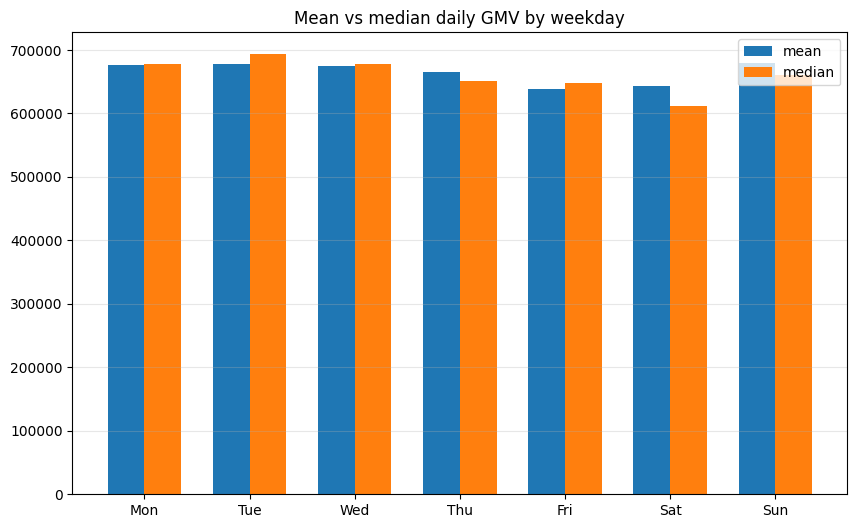

In [24]:
# WEEKLY MEANS AND MEDIANS OF GMV AGREGATED BY DAYS
weekday_stats = (
    daily.group_by("weekday")
    .agg(
        pl.col("gmv_sum").mean().alias("mean_daily_gmv"),
        pl.col("gmv_sum").median().alias("median_daily_gmv"),
    )
    .sort("weekday")
)

print(weekday_stats)

x = np.arange(1, 8)
width = 0.35

fig, ax = plt.subplots(figsize = (10, 6))

ax.bar(x - width / 2, weekday_stats["mean_daily_gmv"], width = width, label = "mean")
ax.bar(x + width / 2, weekday_stats["median_daily_gmv"], width = width, label = "median")

ax.set_xticks(x)
ax.set_xticklabels(WEEKDAY_LABELS)

ax.set_title("Mean vs median daily GMV by weekday")
ax.legend()
ax.grid(alpha = 0.3, axis = "y")

fig.savefig(REPORTS_DIR / "04_weekday_mean_median.png", dpi = 150)
plt.show()

### **Thoughts:**
- Interesting that at the beginning of the week users generate higher GMV;
- At the beginning of the week median can be higher than mean, the absolute opposite on weekends. As we can see thank to boxplots because of increasing outliers' amount. Less group of consumers gpoduce higher cheques than a tipical platform user;
- Also Tuesday makes as wonder if there’s a pattern here in fact of a noticeable difference between mean and median, the 2nd of each is higher.

*At any point it's necessery to prove statistic significance of differences*

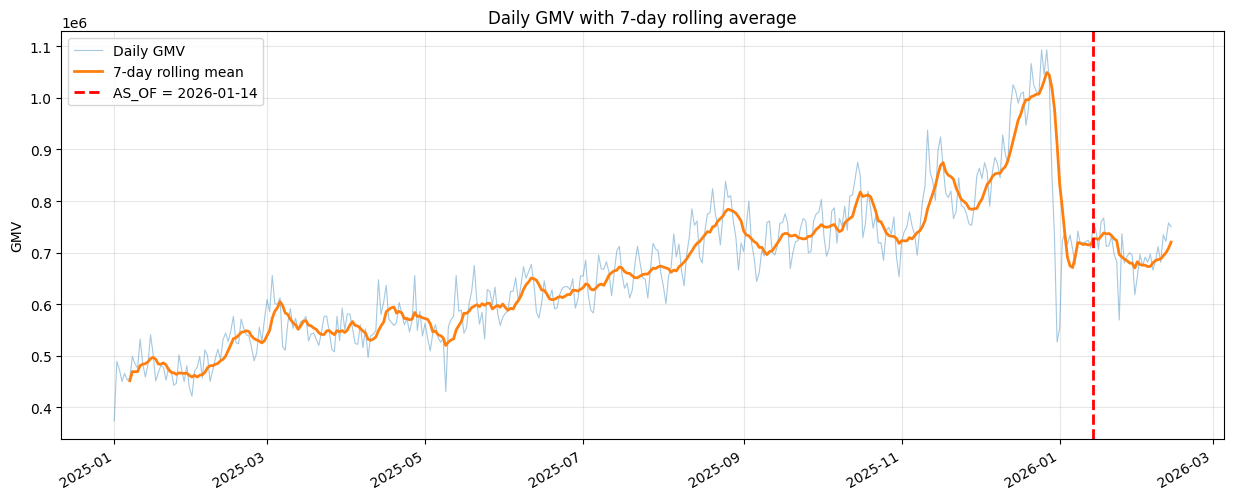

In [25]:
# DAILY DINAMIC CHART WITH AS_OF
daily_sorted = daily.sort("event_date")

dates = daily_sorted["event_date"].to_list()
gmv = daily_sorted["gmv_sum"].to_numpy()

# WEEKLY ROLLING MEAN 
window = 7
rolling_mean = pd.Series(gmv).rolling(window).mean().to_numpy()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(dates, gmv, alpha = 0.4, linewidth = 0.8, label = "Daily GMV")
ax.plot(dates, rolling_mean, color = "tab:orange", linewidth = 2, label = f"7-day rolling mean")
ax.axvline(AS_OF, color = "red", linestyle = "--", linewidth = 2, label = "AS_OF = 2026-01-14")

ax.set_title("Daily GMV with 7-day rolling average")
ax.set_ylabel("GMV")
ax.legend()
ax.grid(alpha = 0.3)

fig.autofmt_xdate()
fig.savefig(REPORTS_DIR / "05_daily_gmv_rolling.png", dpi = 150)
plt.show()

### **Thoughts:**
- Our previous thoughts are getting more plausible after taking a glimpse of daily GMV with 7-day rolling average gragh. As we can see, oscillations are occurring. Which is very important, oscillations are stable for some horizon like local 2-4 weeks, discarding the positive shocks of the festive hustle and bustle. So if we look at 1st-3rd weeks of February we can notice this pattern. Similar patterns are noticeable on 3rd week of May - 1st week of June, 4th week of June - 2nd week of July etc.;
- As we look closely to `AS_OF` timepos, we can notice how consumption is adjusted after the New Year holidays, than enters the next monthly phase of the recession from 3rd week of January to 2nd week of February. This pattern is similar to the situation during the same period of 2025 year;
- Since this moment we can project the experience of 2025 onto the target period of 2026, adjusting for the annual cycle.